# 02 · Engenharia de dados

Tarefa 2 do desafio: criar variáveis derivadas *se fizer sentido* e explicar o tratamento de dados ausentes ou inconsistentes.

O "se fizer sentido" é a parte que este notebook leva a sério. Em vez de inventar um punhado de variáveis compostas e assumir que ajudam, cada candidata é medida contra as colunas originais que a formaram. Quem não ganha das próprias partes é descartada, com o número que a reprovou registrado.

### Índice

1. Setup
2. Leitura e tipagem
3. Tratamento dos ausentes
4. Ordinais
5. Variáveis derivadas
6. Base final
7. Síntese

Herda do [notebook 01](01_exploracao_inicial.ipynb) o diagnóstico que justifica cada decisão daqui.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CSV = Path("../data/raw/habitos_e_desempenho_estudantil.csv")
if not CSV.exists():
    CSV = Path("data/raw/habitos_e_desempenho_estudantil.csv")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

print(f"pandas {pd.__version__}  ·  numpy {np.__version__}")

pandas 3.0.6  ·  numpy 2.5.3


In [2]:
# Mesma paleta e mesmo estilo do notebook 01, para que os gráficos dos dois
# tenham a mesma leitura. Azul é sempre "o dado", vermelho sempre "tem problema".
COR = {
    "serie_1":    "#2a78d6",
    "serie_2":    "#eb6834",
    "critico":    "#d03b3b",
    "superficie": "#fcfcfb",
    "tinta":      "#0b0b0b",
    "tinta_2":    "#52514e",
    "suave":      "#898781",
    "grade":      "#e1e0d9",
    "eixo":       "#c3c2b7",
}

plt.rcParams.update({
    "figure.facecolor":   COR["superficie"],
    "axes.facecolor":     COR["superficie"],
    "savefig.facecolor":  COR["superficie"],
    "figure.dpi":         110,
    "font.family":        "sans-serif",
    "font.size":          9.5,
    "text.color":         COR["tinta"],
    "axes.titlesize":     10.5,
    "axes.titleweight":   "bold",
    "axes.titlecolor":    COR["tinta"],
    "axes.titlelocation": "left",
    "axes.titlepad":      9,
    "axes.labelsize":     9,
    "axes.labelcolor":    COR["tinta_2"],
    "axes.edgecolor":     COR["eixo"],
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "axes.axisbelow":     True,
    "grid.color":         COR["grade"],
    "grid.linewidth":     0.8,
    "grid.linestyle":     "-",
    "xtick.color":        COR["suave"],
    "ytick.color":        COR["suave"],
    "xtick.labelsize":    8.5,
    "ytick.labelsize":    8.5,
    "xtick.bottom":       False,
    "ytick.left":         False,
    "legend.frameon":     False,
    "legend.fontsize":    9,
})


def so_grade(ax, eixo="y"):
    "Deixa grade em um eixo só. O dado é a única coisa que pode ser forte."
    ax.grid(axis=eixo, visible=True)
    ax.grid(axis="x" if eixo == "y" else "y", visible=False)
    return ax

## 2. Leitura e tipagem

In [3]:
# Leitura crua e conversão explícita, iguais às do notebook 01. O motivo está lá
# na seção 2: um read_csv padrão converteria a string "None" de
# parental_education_level em NaN, criando 91 ausentes que não existem no arquivo.
INTEIRAS = ["age", "exercise_frequency", "mental_health_rating"]
DECIMAIS = [
    "study_hours_per_day", "social_media_hours", "netflix_hours",
    "attendance_percentage", "sleep_hours", "exam_score",
]

cru = pd.read_csv(CSV, dtype=str, na_filter=False)

df = cru.copy()
df[INTEIRAS] = df[INTEIRAS].astype(int)
df[DECIMAIS] = df[DECIMAIS].astype(float)

print(f"{df.shape[0]} linhas × {df.shape[1]} colunas  ·  NaN: {int(df.isna().sum().sum())}")

1000 linhas × 16 colunas  ·  NaN: 0


## 3. Tratamento dos ausentes

O notebook 01 estabeleceu duas coisas sobre `parental_education_level`: a string `"None"` aparece em 91 linhas (9,1%), e a coluna **não prevê a nota** (as quatro médias cabem em 2,2 pontos contra um desvio-padrão de 16,9, e `Master` é a menor delas).

Isso decide o tratamento sem precisar resolver se `"None"` significa "sem educação formal" ou "não respondeu": o `"None"` fica como está, uma string. A razão é prática, não semântica.

In [4]:
# Se o "None" virasse NaN, todo dropna() adiante cortaria 9,1% da amostra por
# causa de uma coluna que não explica a nota. Este é o custo, medido:
n_none = int(cru["parental_education_level"].eq("None").sum())

print(f"linhas com 'None'                       : {n_none} ({100 * n_none / len(df):.1f}%)")
print(f"linhas sobreviventes a um dropna ingênuo: {len(df) - n_none}")
print(f"NaN na base como está tratada           : {int(df.isna().sum().sum())}")

linhas com 'None'                       : 91 (9.1%)
linhas sobreviventes a um dropna ingênuo: 909
NaN na base como está tratada           : 0


Nenhuma linha é descartada, nenhum valor é imputado e nada é preenchido. **A base não tem ausente**, e a única coisa que poderia criá-los era a leitura, que já foi contornada na seção 2.

Vale dizer o que *não* foi feito, porque a ausência de tratamento também é uma decisão: não removi outliers (o notebook 01 mostrou que praticamente não há, e os poucos das pontas são plausíveis), não removi duplicatas (não existem) e não corrigi rótulos categóricos (já estão padronizados).

## 4. Ordinais

Cinco colunas carregam ordem que o tipo não expressa. Três chegam como texto, e para o pandas `"Poor"`, `"Fair"` e `"Good"` são apenas três strings sem relação entre si. Um `groupby` as ordenaria alfabeticamente, colocando `Fair` antes de `Good` antes de `Poor`, que não é a escala.

In [5]:
# Ordem declarada à mão, porque nenhuma delas é inferível do dado.
# "None" entra como degrau mais baixo da escolaridade. É uma suposição, e ela sai
# de graça: o notebook 01 mostrou que essa coluna não prevê a nota de nenhum jeito,
# então tanto faz se o degrau está no lugar certo.
ORDINAIS = {
    "diet_quality":             ["Poor", "Fair", "Good"],
    "internet_quality":         ["Poor", "Average", "Good"],
    "parental_education_level": ["None", "High School", "Bachelor", "Master"],
}

for coluna, ordem in ORDINAIS.items():
    df[coluna] = pd.Categorical(df[coluna], categories=ordem, ordered=True)
    # A coluna _cod guarda a posição na escala. O Categorical preserva o rótulo
    # para leitura; o inteiro é o que entra em correlação no notebook 03.
    df[f"{coluna}_cod"] = df[coluna].cat.codes

df[[c for c in df.columns if c in ORDINAIS or c.endswith("_cod")]].head(5)

,diet_quality,parental_education_level,internet_quality,diet_quality_cod,internet_quality_cod,parental_education_level_cod
0,Fair,Master,Average,1,1,3
1,Good,High School,Average,2,1,1
2,Poor,High School,Poor,0,0,1
3,Poor,Master,Good,0,2,3
4,Fair,Master,Good,1,2,3


In [6]:
# Confere que a ordem pegou: com Categorical ordenado, comparação funciona.
amostra = df["diet_quality"]
print("Poor < Good ?", amostra.min() == "Poor", "| ordem:", list(amostra.cat.categories))
print()

# E que o código numérico acompanha a escala, não o alfabeto.
print(df.groupby("diet_quality", observed=True)["diet_quality_cod"].first())

Poor < Good ? True | ordem: ['Poor', 'Fair', 'Good']

diet_quality
Poor    0
Fair    1
Good    2
Name: diet_quality_cod, dtype: int8


`mental_health_rating` (1 a 10) também é ordinal, mas chega como inteiro na ordem certa e fica como está. `exercise_frequency` (0 a 6) também chega como inteiro, mas é dias por semana, uma contagem real, não uma escala subjetiva: não carrega a mesma ressalva, e fica como está por ser numérica de verdade, não por aproximação.

Uma ressalva que vale para as quatro ordinais, as três de texto mais `mental_health_rating`: **ordem não é distância**. Que `Good` venha depois de `Fair` não significa que o salto de `Fair` para `Good` seja igual ao de `Poor` para `Fair`, e saúde mental 8 não é o dobro de 4. Tratá-las como número em correlação de Pearson, que é o que o notebook 03 vai fazer, assume exatamente isso. É uma aproximação aceitável e comum, mas é uma aproximação, e o notebook 03 vai conferir o resultado com Spearman, que só usa a ordem.

## 5. Variáveis derivadas

Aqui está a pergunta que dá trabalho responder direito. É fácil montar dez variáveis compostas que *parecem* inteligentes: horas produtivas, razão estudo sobre lazer, índice geral de hábitos. É bem mais raro checar se alguma delas realmente explica melhor que as colunas de onde saiu.

O critério aplicado é esse: **uma derivada só existe se explicar a nota melhor do que a melhor das suas próprias componentes.** Se não bater as partes, ela está adicionando ruído e custo de manutenção em troca de nada.

### 5.1 As candidatas e o teste

In [7]:
alvo = df["exam_score"]

# Sete hipóteses. Cada uma afirma: "combinar essas colunas explica a nota melhor
# do que elas separadas".
candidatas = {
    "tempo_tela_total":   df["social_media_hours"] + df["netflix_hours"],
    "horas_produtivas":   df["study_hours_per_day"] * df["attendance_percentage"] / 100,
    "estudo_menos_tela":  df["study_hours_per_day"] - (df["social_media_hours"] + df["netflix_hours"]),
    "razao_estudo_tela":  df["study_hours_per_day"] / (df["social_media_hours"] + df["netflix_hours"] + 0.5),
    "indice_habitos": (
        df["study_hours_per_day"] / df["study_hours_per_day"].std()
        + df["exercise_frequency"] / df["exercise_frequency"].std()
        - (df["social_media_hours"] + df["netflix_hours"]) / (df["social_media_hours"] + df["netflix_hours"]).std()
    ),
    "sono_desvio_8h":     (df["sleep_hours"] - 8).abs(),
    "sono_insuficiente":  (df["sleep_hours"] < 6).astype(int),
}

# De quais colunas originais cada candidata foi feita. É contra a melhor dessas
# que ela precisa ganhar, não contra a base inteira.
COMPONENTES = {
    "tempo_tela_total":  ["social_media_hours", "netflix_hours"],
    "horas_produtivas":  ["study_hours_per_day", "attendance_percentage"],
    "estudo_menos_tela": ["study_hours_per_day", "social_media_hours", "netflix_hours"],
    "razao_estudo_tela": ["study_hours_per_day", "social_media_hours", "netflix_hours"],
    "indice_habitos":    ["study_hours_per_day", "exercise_frequency",
                          "social_media_hours", "netflix_hours"],
    "sono_desvio_8h":    ["sleep_hours"],
    "sono_insuficiente": ["sleep_hours"],
}

linhas = []
for nome, serie in candidatas.items():
    r_derivada = serie.corr(alvo)
    # Compara em módulo: uma correlação de -0,24 é sinal mais forte que uma de +0,17.
    partes = {c: df[c].corr(alvo) for c in COMPONENTES[nome]}
    melhor = max(partes, key=lambda c: abs(partes[c]))
    linhas.append({
        "derivada": nome,
        "r": r_derivada,
        "melhor_componente": melhor,
        "r_componente": partes[melhor],
        "ganho": abs(r_derivada) - abs(partes[melhor]),
    })

teste = pd.DataFrame(linhas).set_index("derivada").sort_values("ganho", ascending=False)
teste["veredito"] = np.where(teste["ganho"] > 0, "mantém", "descarta")
teste

,r,melhor_componente,r_componente,ganho,veredito
derivada,,,,,
tempo_tela_total,-0.238,netflix_hours,-0.172,0.066,mantém
sono_desvio_8h,-0.120,sleep_hours,0.122,-0.001,descarta
horas_produtivas,0.809,study_hours_per_day,0.825,-0.016,descarta
sono_insuficiente,-0.088,sleep_hours,0.122,-0.034,descarta
estudo_menos_tela,0.731,study_hours_per_day,0.825,-0.094,descarta
indice_habitos,0.704,study_hours_per_day,0.825,-0.121,descarta
razao_estudo_tela,0.637,study_hours_per_day,0.825,-0.189,descarta


### 5.2 O resultado, em um gráfico

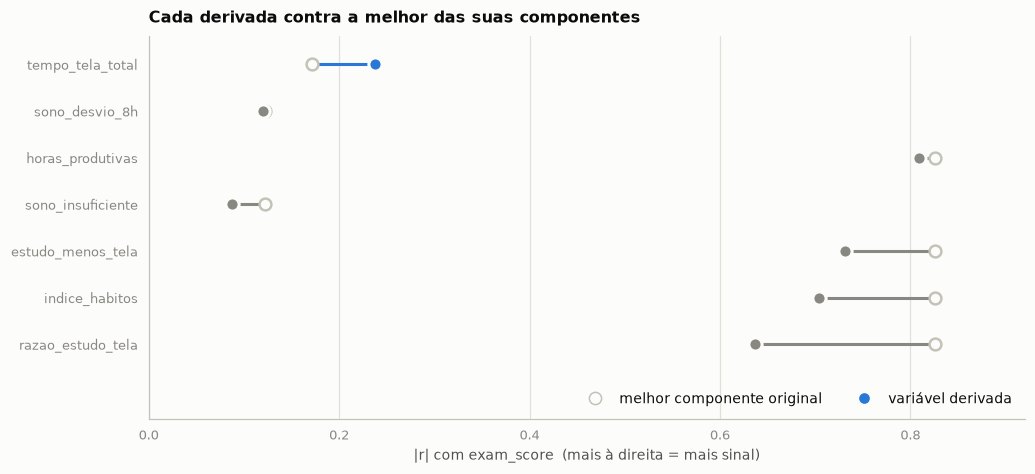

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))

t = teste.sort_values("ganho")

# Halteres: círculo vazio é a melhor componente original, círculo cheio é a
# derivada. Se o cheio está à direita do vazio, a combinação ganhou sinal.
# Só a sobrevivente recebe cor; as reprovadas ficam em cinza.
for i, (nome, linha) in enumerate(t.iterrows()):
    ganhou = linha["ganho"] > 0
    cor = COR["serie_1"] if ganhou else COR["suave"]
    origem, destino = abs(linha["r_componente"]), abs(linha["r"])

    ax.plot([origem, destino], [i, i], color=cor, linewidth=2, zorder=2)
    ax.scatter(origem, i, s=60, color=COR["superficie"],
               edgecolor=COR["eixo"], linewidth=1.6, zorder=3)
    ax.scatter(destino, i, s=75, color=cor,
               edgecolor=COR["superficie"], linewidth=2, zorder=4)

ax.set_yticks(np.arange(len(t)), t.index)
ax.set_xlabel("|r| com exam_score  (mais à direita = mais sinal)")
ax.set_title("Cada derivada contra a melhor das suas componentes")
ax.set_xlim(0, 0.92)
# Abre uma faixa vazia embaixo para a legenda, que senão cobre a última linha.
ax.set_ylim(-1.6, len(t) - 0.4)

# Legenda por artistas de apoio, já que os marcadores são desenhados à mão.
from matplotlib.lines import Line2D
ax.legend(
    handles=[
        Line2D([], [], marker="o", linestyle="", markersize=8,
               markerfacecolor=COR["superficie"], markeredgecolor=COR["eixo"],
               label="melhor componente original"),
        Line2D([], [], marker="o", linestyle="", markersize=8,
               markerfacecolor=COR["serie_1"], markeredgecolor=COR["superficie"],
               label="variável derivada"),
    ],
    loc="lower right", ncol=2,
)
so_grade(ax, eixo="x")
plt.tight_layout()
plt.show()

**De sete candidatas, uma sobrevive.**

`tempo_tela_total` é a única que ganha das próprias partes: r de -0,238, contra -0,172 do streaming e -0,167 das redes sociais isoladamente. Faz sentido, e o sentido é bem prosaico: as duas colunas medem o mesmo comportamento, tempo gasto em tela por lazer, repartido em dois lugares. Somá-las junta um sinal que estava dividido.

As outras seis perdem, e vale olhar como perdem:

1. **`horas_produtivas`** (estudo × frequência) dá 0,809 contra 0,825 do estudo puro. Multiplicar pela frequência *diluiu* o melhor preditor da base, porque `attendance_percentage` mal se correlaciona com a nota (0,090).
2. **`razao_estudo_tela`** despenca para 0,637. Razões são traiçoeiras: comprimem quem estuda muito e quem usa pouca tela na mesma região, e jogam fora a escala.
3. **`indice_habitos`** (0,704) é o exemplo clássico do índice composto que soa bem e entrega menos: misturar um preditor forte com dois fracos puxa o resultado para o meio.
4. **`sono_desvio_8h` e `sono_insuficiente`** falham porque partem de uma premissa que o dado não sustenta.

In [9]:
# A premissa do sono era que existe uma faixa ótima e que afastar-se dela faz mal.
# Se fosse verdade, a média cairia nas duas pontas.
faixas_sono = pd.cut(df["sleep_hours"], [0, 5, 6, 7, 8, 9, 24], right=False)
print(df.groupby(faixas_sono, observed=True)["exam_score"].agg(["size", "mean"]))
print()

# E nenhum ponto de corte para "dormiu pouco" bate o sono contínuo (r = +0,122).
print("r de sono_insuficiente por ponto de corte:")
for corte in [5, 5.5, 6, 6.5, 7]:
    r = (df["sleep_hours"] < corte).astype(int).corr(alvo)
    print(f"  < {corte}h  r = {r:+.3f}")

             size   mean
sleep_hours             
[0, 5)        109 65.008
[5, 6)        234 68.741
[6, 7)        312 69.072
[7, 8)        226 72.972
[8, 9)         93 69.839
[9, 24)        26 72.812

r de sono_insuficiente por ponto de corte:
  < 5h  r = -0.095
  < 5.5h  r = -0.076
  < 6h  r = -0.088
  < 6.5h  r = -0.112
  < 7h  r = -0.108


Não há U invertido. A média sobe de 65,0 (menos de 5h) até 73,0 (7h a 8h) e depois **não volta a cair**: quem dorme 9h ou mais tem média 72,8. O sono não tem ponto ótimo nesta base, tem um piso ruim. E como a relação é aproximadamente monótona, a coluna contínua já captura tudo que há para capturar. Nenhum corte entre 5h e 7h chega perto dos +0,122 do `sleep_hours` original.

Descartar as seis é o resultado útil do teste, não um fracasso dele. Cada uma sai documentada com o número que a reprovou, para que ninguém (inclusive eu, daqui a três semanas) refaça a mesma tentativa achando que é nova.

### 5.3 Faixas, que servem a outro propósito

As faixas abaixo são criadas **apesar** do teste acima, não por causa dele, e é importante dizer por quê.

Discretizar uma variável contínua sempre joga informação fora. Uma faixa nunca vai prever melhor que a coluna que a originou, e usar `faixa_estudo` num modelo em vez de `study_hours_per_day` seria um erro claro.

Elas existem para **comunicar e segmentar**: boxplot por faixa (tarefa 5), recorte de grupos para recomendação (tarefas 4 e 6), leitura de "alunos que estudam de 2h a 3h" num relatório. Para esse uso, a perda de informação é o objetivo, porque o que se ganha é uma categoria que uma pessoa consegue reter.

In [10]:
# Cortes em hora cheia, e não em quartil. O quartil de social_media_hours cairia
# em 1,7 e 3,3, e "entre 1,7h e 3,3h" não é algo que alguém repita numa reunião.
FAIXAS = {
    "faixa_estudo": (
        "study_hours_per_day", [0, 2, 3, 4, 5, np.inf],
        ["menos de 2h", "2h a 3h", "3h a 4h", "4h a 5h", "5h ou mais"],
    ),
    "faixa_redes": (
        "social_media_hours", [0, 1, 2, 3, 4, np.inf],
        ["menos de 1h", "1h a 2h", "2h a 3h", "3h a 4h", "4h ou mais"],
    ),
    "faixa_sono": (
        "sleep_hours", [0, 6, 7, 8, np.inf],
        ["menos de 6h", "6h a 7h", "7h a 8h", "8h ou mais"],
    ),
}

for nova, (origem, cortes, rotulos) in FAIXAS.items():
    df[nova] = pd.cut(df[origem], bins=cortes, labels=rotulos, right=False, ordered=True)

df[list(FAIXAS)].apply(lambda s: s.value_counts().reindex(s.cat.categories)).T

,1h a 2h,2h a 3h,3h a 4h,4h a 5h,4h ou mais,5h ou mais,6h a 7h,7h a 8h,8h ou mais,menos de 1h,menos de 2h,menos de 6h
faixa_estudo,NaN,201.000,281.000,218.000,NaN,167.000,NaN,NaN,NaN,NaN,133.000,NaN
faixa_redes,227.000,311.000,251.000,NaN,113.000,NaN,NaN,NaN,NaN,98.000,NaN,NaN
faixa_sono,NaN,NaN,NaN,NaN,NaN,NaN,312.000,226.000,119.000,NaN,NaN,343.000


In [11]:
# A derivada que sobreviveu entra na base.
df["tempo_tela_total"] = df["social_media_hours"] + df["netflix_hours"]

print(f"tempo_tela_total  r = {df['tempo_tela_total'].corr(alvo):+.3f}")
print(f"  social_media    r = {df['social_media_hours'].corr(alvo):+.3f}")
print(f"  netflix         r = {df['netflix_hours'].corr(alvo):+.3f}")

tempo_tela_total  r = -0.238
  social_media    r = -0.167
  netflix         r = -0.172


## 6. Base final

Tudo que foi decidido acima cabe numa função. Os notebooks 03 a 06 começam chamando ela, em vez de repetir as transformações e correr o risco de divergirem entre si.

In [12]:
def preparar_dados(csv=CSV):
    "Lê o CSV cru e devolve a base tratada, pronta para os notebooks 03 a 06."
    # Leitura crua: nenhuma conversão automática, nenhum NaN inventado.
    base = pd.read_csv(csv, dtype=str, na_filter=False)

    # Tipagem explícita. parental_education_level segue texto, com o "None" intacto.
    base[INTEIRAS] = base[INTEIRAS].astype(int)
    base[DECIMAIS] = base[DECIMAIS].astype(float)

    # Ordinais: rótulo ordenado para ler, código inteiro para calcular.
    for coluna, ordem in ORDINAIS.items():
        base[coluna] = pd.Categorical(base[coluna], categories=ordem, ordered=True)
        base[f"{coluna}_cod"] = base[coluna].cat.codes

    # Única derivada aprovada no teste da seção 5.
    base["tempo_tela_total"] = base["social_media_hours"] + base["netflix_hours"]

    # Faixas, para comunicação e segmentação. Nunca para modelo.
    for nova, (origem, cortes, rotulos) in FAIXAS.items():
        base[nova] = pd.cut(base[origem], bins=cortes, labels=rotulos,
                            right=False, ordered=True)

    return base


tratada = preparar_dados()
print(f"{tratada.shape[0]} linhas × {tratada.shape[1]} colunas "
      f"({tratada.shape[1] - 16} colunas novas)")
print(f"NaN: {int(tratada.isna().sum().sum())}")

1000 linhas × 23 colunas (7 colunas novas)
NaN: 0


In [13]:
tratada.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   student_id                     1000 non-null   str     
 1   age                            1000 non-null   int64   
 2   gender                         1000 non-null   str     
 3   study_hours_per_day            1000 non-null   float64 
 4   social_media_hours             1000 non-null   float64 
 5   netflix_hours                  1000 non-null   float64 
 6   part_time_job                  1000 non-null   str     
 7   attendance_percentage          1000 non-null   float64 
 8   sleep_hours                    1000 non-null   float64 
 9   diet_quality                   1000 non-null   category
 10  exercise_frequency             1000 non-null   int64   
 11  parental_education_level       1000 non-null   category
 12  internet_quality               1000 non-null  

In [14]:
# Confere que a função reproduz exatamente o que foi construído passo a passo
# ao longo do notebook, sem nenhuma transformação ter ficado de fora.
colunas_comuns = sorted(set(df.columns) & set(tratada.columns))
iguais = all(df[c].equals(tratada[c]) for c in colunas_comuns)

print(f"colunas em comum : {len(colunas_comuns)}")
print(f"conteúdo idêntico: {iguais}")
print(f"colunas só no df : {sorted(set(df.columns) - set(tratada.columns))}")

colunas em comum : 23
conteúdo idêntico: True
colunas só no df : []


## 7. Síntese

### Tratamento de ausentes e inconsistências

Nenhuma linha removida, nenhum valor imputado, nenhum rótulo corrigido. A base não precisava de nada disso, e o notebook 01 mostrou por quê. O único trabalho real foi **impedir que a leitura criasse 91 ausentes** que o arquivo não tem.

### O que entrou na base

| Coluna nova | Origem | Serve para |
|---|---|---|
| `diet_quality_cod`, `internet_quality_cod`, `parental_education_level_cod` | ordinais de texto | Correlação no notebook 03, preservando a ordem da escala |
| `tempo_tela_total` | `social_media_hours` + `netflix_hours` | Único composto que ganha das partes: r de -0,238 contra -0,172 e -0,167 |
| `faixa_estudo`, `faixa_redes`, `faixa_sono` | cortes de hora cheia | Comunicação e segmentação (tarefas 4 a 6). **Não** para modelo |

### O que foi testado e descartado

| Candidata | r | Melhor componente | Por quê caiu |
|---|---|---|---|
| `horas_produtivas` | +0,809 | `study_hours_per_day` +0,825 | Multiplicar pela frequência dilui o melhor preditor |
| `estudo_menos_tela` | +0,731 | `study_hours_per_day` +0,825 | Subtrair um sinal fraco de um forte só adiciona ruído |
| `indice_habitos` | +0,704 | `study_hours_per_day` +0,825 | Índice composto puxa o preditor forte para a média |
| `razao_estudo_tela` | +0,637 | `study_hours_per_day` +0,825 | Razão comprime a escala e perde informação |
| `sono_desvio_8h` | -0,120 | `sleep_hours` +0,122 | Não existe faixa ótima de sono nesta base |
| `sono_insuficiente` | -0,088 | `sleep_hours` +0,122 | Nenhum ponto de corte bate a coluna contínua |

### A lição

**Seis de sete variáveis derivadas pioraram o sinal.** A base já vinha com `study_hours_per_day`, que sozinha correlaciona +0,825 com a nota, e nenhuma combinação que montei chegou perto disso. Engenharia de variável não é criar quantas couberem, é descobrir quais poucas fazem diferença, e o teste é barato: comparar cada composta com a melhor das suas partes.

### Próximo passo

**Notebook 03, análise estatística**: matriz de correlação, Pearson contra Spearman (para conferir a aproximação feita nas ordinais), e quais hábitos têm maior influência positiva e negativa sobre a nota.